<a href="https://colab.research.google.com/github/Baidunafter/NN/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [ ]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

print("Размер данных:", df.shape)
df.head()

Размер данных: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


#### 1.2. Проектируем архитектуру для этой задачи

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

X = df[feature_names].values
y = df['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

#### 1.4. Обучаем модель ИНС

In [ ]:
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=32,
                    verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 620.1130 - mae: 22.9195 - val_loss: 546.7404 - val_mae: 21.7861
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 594.6412 - mae: 22.3338 - val_loss: 523.2788 - val_mae: 21.1958
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 568.4985 - mae: 21.6468 - val_loss: 490.8396 - val_mae: 20.3539
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 526.4803 - mae: 20.5759 - val_loss: 441.5418 - val_mae: 19.0195
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 466.5073 - mae: 19.0131 - val_loss: 369.8544 - val_mae: 17.0695
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 379.0571 - mae: 16.6161 - val_loss: 275.2547 - val_mae: 14.3014
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 272.7680 - mae: 13.7104 - val_loss: 169.6497 - val_mae: 10.6082
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 170.3205 - mae: 10.3763 - val_loss: 86.7358 - val_mae: 6.9285
Epoch 9/100
11/11

#### 1.6. Делаем предсказания на тестовых данных

In [ ]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2.41
MSE: 13.47
RMSE: 3.67


#### 1.8. Строим график обучения

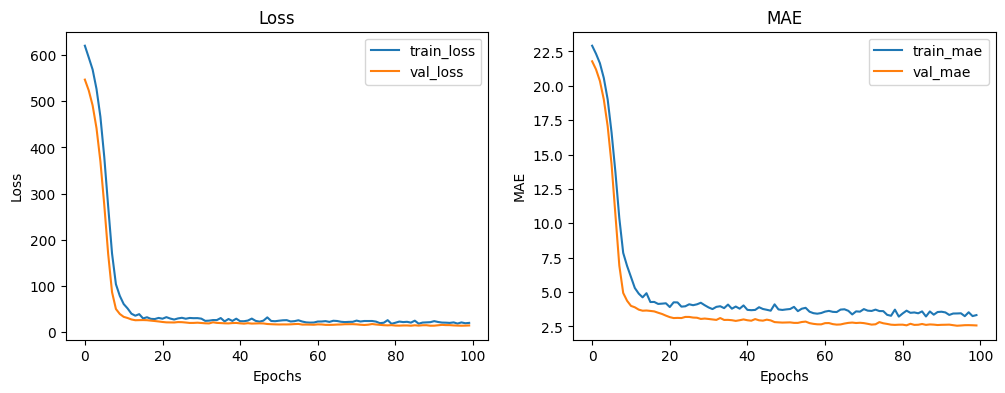

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [ ]:
!pip install gradio

import gradio as gr

def predict_price(crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat):
    features = np.array([[crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat]])
    features_scaled = scaler.transform(features)
    pred = model.predict(features_scaled)[0][0]
    return f"Предсказанная цена: ${pred:.2f}k"

inputs = [
    gr.Number(label="CRIM (уровень преступности)"),
    gr.Number(label="ZN (доля жилой земли)"),
    gr.Number(label="INDUS (доля промышленной зоны)"),
    gr.Number(label="CHAS (рядом с рекой? 0/1)"),
    gr.Number(label="NOX (концентрация оксидов азота)"),
    gr.Number(label="RM (среднее число комнат)"),
    gr.Number(label="AGE (доля старых домов)"),
    gr.Number(label="DIS (расстояние до центров занятости)"),
    gr.Number(label="RAD (индекс доступности радиальных дорог)"),
    gr.Number(label="TAX (налог на недвижимость)"),
    gr.Number(label="PTRATIO (соотношение ученики/учителя)"),
    gr.Number(label="B (доля афроамериканцев)"),
    gr.Number(label="LSTAT (% населения с низким статусом)")
]

output = gr.Textbox(label="Результат")

gr.Interface(fn=predict_price, inputs=inputs, outputs=output, title="Предсказание цен на жильё в Бостоне").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c38379fe23b7ddffb1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
sample = X_test[0].reshape(1, -1)
pred = model.predict(sample)[0][0]
print(f"Предсказание: {pred:.2f}, Истинное значение: {y_test[0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Предсказание: 28.22, Истинное значение: 23.60


## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [ ]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedaziz15/cars-brands-in-egypt")

print("Path to dataset files:", path)

100%|██████████| 800M/800M [00:10<00:00, 83.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohamedaziz15/cars-brands-in-egypt/versions/4


### 3. Указываем путь к набору данных:

In [ ]:
dataset_path = path

### 4. Загружаем набор данных и формируем общую выборку:

In [ ]:
import os
import cv2
import numpy as np
from imutils import paths
import random
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from collections import Counter

brands = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print("Все бренды:", brands)

valid_brands = []
for brand in brands:
    brand_dir = os.path.join(dataset_path, brand)
    images = list(paths.list_images(brand_dir))
    count = len(images)
    print(f"{brand}: {count} изображений")
    if count >= 1000:
        valid_brands.append((brand, count))

valid_brands.sort(key=lambda x: x[1], reverse=True)
selected_brands = [b[0] for b in valid_brands[:3]]
print(f"\nВыбраны бренды: {selected_brands}")
counts_dict = dict(valid_brands)
min_count = min(counts_dict[brand] for brand in selected_brands)

data = []
labels = []
target_size = (64, 64)

for brand in selected_brands:
    brand_dir = os.path.join(dataset_path, brand)
    image_paths = list(paths.list_images(brand_dir))
    random.shuffle(image_paths)
    for path in image_paths[:min_count]:
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.resize(image, target_size)
        data.append(image)
        labels.append(brand)

print(f"Всего загружено изображений: {len(data)}")
print("Распределение по классам:")
print(Counter(labels))

Все бренды: ['Mercedes-Benz', 'Chevrolet', 'Mitsubishi', 'BMW', 'Honda', 'volkswagen', 'Renault', 'nissan', 'Toyota', 'Suzuki', 'Byd', 'Ford', 'kia', 'Skoda', 'Hundai', 'lada']
Mercedes-Benz: 823 изображений
Chevrolet: 808 изображений
Mitsubishi: 661 изображений
BMW: 994 изображений
Honda: 898 изображений
volkswagen: 425 изображений
Renault: 922 изображений
nissan: 514 изображений
Toyota: 1232 изображений
Suzuki: 1448 изображений
Byd: 252 изображений
Ford: 932 изображений
kia: 691 изображений
Skoda: 487 изображений
Hundai: 1176 изображений
lada: 206 изображений

Выбраны бренды: ['Suzuki', 'Toyota', 'Hundai']
Всего загружено изображений: 3528
Распределение по классам:
Counter({'Suzuki': 1176, 'Toyota': 1176, 'Hundai': 1176})


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [ ]:
data = np.array(data, dtype="float32") / 255.0
labels = np.array(labels)

#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [ ]:
lb = LabelBinarizer()
labels_bin = lb.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels_bin, test_size=0.25, random_state=42, stratify=labels_bin
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Классы:", lb.classes_)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

Train shape: (2646, 64, 64, 3)
Test shape: (882, 64, 64, 3)
Классы: ['Hundai' 'Suzuki' 'Toyota']


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


input_dim = X_train_flat.shape[1]
num_classes = len(selected_brands)

model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,579 (24.63 MB)

 Trainable params: 6,456,579 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [ ]:
INIT_LR = 0.001
EPOCHS = 100
BATCH_SIZE = 32

#### 5.3. Компилируем модель:

In [ ]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=INIT_LR)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_car_model.h5",
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

#### 6.2. Запустим процесс обучения модели:

In [ ]:
history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_test_flat, y_test),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3908 - loss: 4.3823
Epoch 1: val_accuracy improved from None to 0.54762, saving model to best_car_model.h5



Epoch 1: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.4195 - loss: 2.7324 - val_accuracy: 0.5476 - val_loss: 0.8901 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5218 - loss: 0.9230
Epoch 2: val_accuracy improved from 0.54762 to 0.56916, saving model to best_car_model.h5



Epoch 2: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5227 - loss: 0.9073 - val_accuracy: 0.5692 - val_loss: 0.7916 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5325 - loss: 0.9005
Epoch 3: val_accuracy improved from 0.56916 to 0.58277, saving model to best_car_model.h5



Epoch 3: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5242 - loss: 0.9010 - val_accuracy: 0.5828 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5328 - loss: 0.8772
Epoch 4: val_accuracy improved from 0.58277 to 0.58617, saving model to best_car_model.h5



Epoch 4: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5325 - loss: 0.8602 - val_accuracy: 0.5862 - val_loss: 0.7896 - learning_rate: 0.0010
Epoch 5/100
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5694 - loss: 0.8183
Epoch 5: val_accuracy did not improve from 0.58617
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5654 - loss: 0.8195 - val_accuracy: 0.5805 - val_loss: 0.7757 - learning_rate: 0.0010
Epoch 6/100
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5644 - loss: 0.8298
Epoch 6: val_accuracy did not improve from 0.58617
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5537 - loss: 0.8364 - val_accuracy: 0.5692 - val_loss: 0.7816 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5595 - loss: 0.8098
Epoch 7: val_accuracy improved from 0.58617 to 0.58957, saving model to best_car_model.h5



Epoch 7: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5525 - loss: 0.8055 - val_accuracy: 0.5896 - val_loss: 0.7614 - learning_rate: 0.0010
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5753 - loss: 0.7855
Epoch 8: val_accuracy improved from 0.58957 to 0.59524, saving model to best_car_model.h5



Epoch 8: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5665 - loss: 0.7791 - val_accuracy: 0.5952 - val_loss: 0.7622 - learning_rate: 0.0010
Epoch 9/100
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5827 - loss: 0.7806
Epoch 9: val_accuracy did not improve from 0.59524
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.5699 - loss: 0.7914 - val_accuracy: 0.5896 - val_loss: 0.7553 - learning_rate: 0.0010
Epoch 10/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5670 - loss: 0.7408
Epoch 10: val_accuracy improved from 0.59524 to 0.59864, saving model to best_car_model.h5



Epoch 10: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5661 - loss: 0.7568 - val_accuracy: 0.5986 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 11/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6064 - loss: 0.7198
Epoch 11: val_accuracy did not improve from 0.59864
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5816 - loss: 0.7299 - val_accuracy: 0.5975 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 12/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6054 - loss: 0.7198
Epoch 12: val_accuracy improved from 0.59864 to 0.61905, saving model to best_car_model.h5



Epoch 12: finished saving model to best_car_model.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.6036 - loss: 0.7055 - val_accuracy: 0.6190 - val_loss: 0.7204 - learning_rate: 0.0010
Epoch 13/100
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5919 - loss: 0.6827
Epoch 13: val_accuracy did not improve from 0.61905
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5862 - loss: 0.7066 - val_accuracy: 0.6122 - val_loss: 0.7117 - learning_rate: 0.0010
Epoch 14/100
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5683 - loss: 0.7412
Epoch 14: val_accuracy did not improve from 0.61905
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5669 - loss: 0.7485 - val_accuracy: 0.5782 - val_loss: 0.7782 - learning_rate: 0.0010
Epoch 15/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5835 - loss: 0.7490
Epoch 15: val_accuracy did not improve from 0.61905
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5809 - loss: 0.7639 - val_accuracy: 0.5952 - val_loss: 

#### 6.3. Загружаем лучшую модель:

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_car_model.h5")
print("Лучшая модель загружена.")

Лучшая модель загружена.


### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [ ]:

from sklearn.metrics import classification_report

y_pred = model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=lb.classes_))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

      Hundai       0.88      0.88      0.88       294
      Suzuki       0.45      0.21      0.29       294
      Toyota       0.50      0.77      0.61       294

    accuracy                           0.62       882
   macro avg       0.61      0.62      0.59       882
weighted avg       0.61      0.62      0.59       882



#### 7.2. Выведем матрицу ошибок

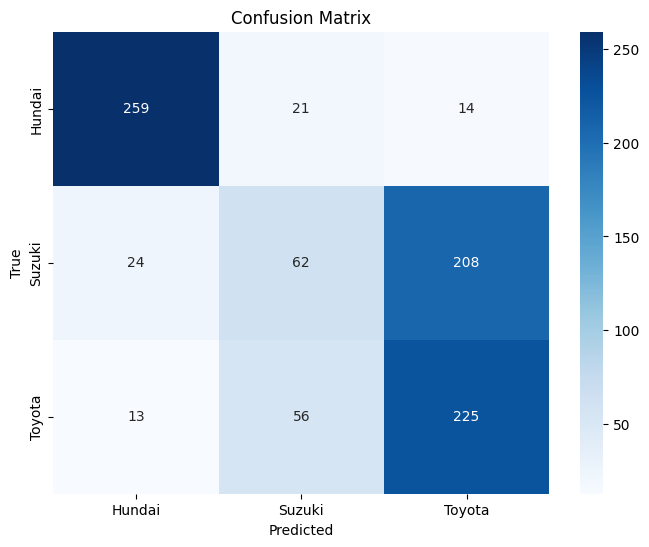

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### 7.3. Отобразим график обучения

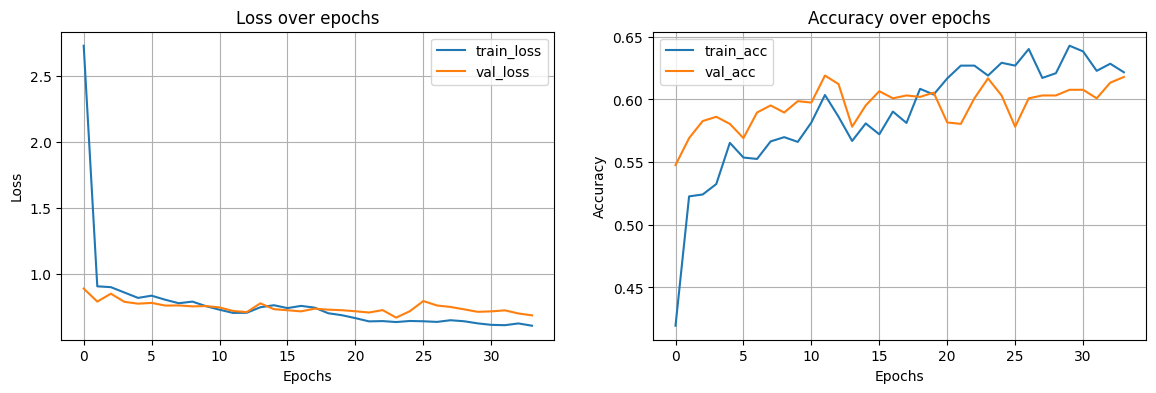

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### 8. Сохранение модели и меток классов:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle
import os

drive_path = "/content/drive/MyDrive/NN_2/"
os.makedirs(drive_path, exist_ok=True)

model.save(drive_path + "final_car_model_cnn.h5")
with open(drive_path + "class_names.pkl", "wb") as f:
    pickle.dump(lb.classes_, f)

### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
from google.colab.patches import cv2_imshow

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [ ]:
def preprocess_image(image_path, target_size=(64,64)):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image = cv2.resize(image, target_size)
    image = image.astype("float32") / 255.0
    image = image.flatten()
    image = np.expand_dims(image, axis=0)
    return image

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [ ]:
def predict_car(image_path, model, class_names):
    processed = preprocess_image(image_path)
    if processed is None:
        return "Ошибка загрузки изображения", 0.0
    preds = model.predict(processed)[0]
    class_idx = np.argmax(preds)
    confidence = preds[class_idx]
    return class_names[class_idx], confidence

### 10. Визуализируем интерфейс и произведем классификацию:

In [ ]:
from tensorflow.keras.models import load_model
import pickle

drive_path = "/content/drive/MyDrive/NN_2/"

model = load_model(drive_path + "final_car_model_cnn.h5")
with open(drive_path + "class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

print("Модель и метки загружены")
print("Классы:", class_names)

Модель и метки загружены
Классы: ['Hundai' 'Suzuki' 'Toyota']


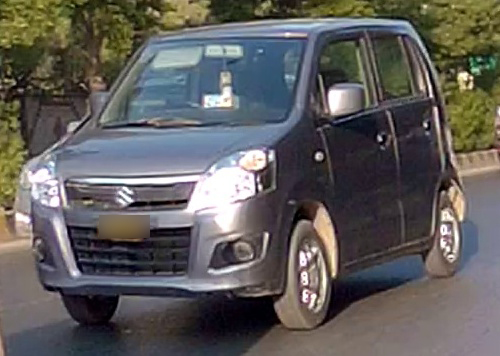

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Истинный класс: Suzuki
Предсказанный класс: Suzuki, уверенность: 0.36


In [ ]:
import random
import os
from google.colab.patches import cv2_imshow

all_images = []
for brand in selected_brands:
    brand_dir = os.path.join(dataset_path, brand)
    for fname in os.listdir(brand_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(brand_dir, fname))

random_path = random.choice(all_images)
img = cv2.imread(random_path)
cv2_imshow(img)

pred_class, confidence = predict_car(random_path, model, lb.classes_)
true_class = os.path.basename(os.path.dirname(random_path))

print(f"Истинный класс: {true_class}")
print(f"Предсказанный класс: {pred_class}, уверенность: {confidence:.2f}")